In [ ]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from joblib import Parallel, delayed



# =========================
# System parameters
# =========================
K_i = 1e-4        # linear stiffness
K_c = 5e10*1e-4       # hardening nonlinearity
K_p = 0.8*1e-4        # NES damping
w1 = 108 * 2 * np.pi  # primary oscillator natural frequency [rad/s]
coupling = 0.09
zeta = 0.0065
Cp = 157e-9
sigma_r = 0.075

# =========================
# Chirp excitation setup
# =========================
a_base_values = np.linspace(5, 45, 12) * 1e-3 *9.8
f0 = 0.5 * w1 / (2 * np.pi)
f1 = 2 * w1 / (2 * np.pi)
t_end = 10

# Time resolution
points_per_period = 100
dt = 1.0 / (points_per_period * f1)
t_eval = np.arange(0.0, t_end , dt)

# Keep all time histories
retain_all_histories = True

def chirp_excitation(t, a_base, f0=f0, f1=f1, t_end=t_end):
    return a_base * np.sin(2 * np.pi * (f0 + t * (f1 - f0) / t_end) * t)


def compute_frf_from_time_domain(t, response, excitation):
    t = np.asarray(t)
    response = np.asarray(response)
    excitation = np.asarray(excitation)

    if response.ndim == 1:
        response = response[:, None]

    dt_local = t[1] - t[0]
    Y = np.fft.fft(response, axis=0)
    X = np.fft.fft(excitation)
    freq = np.fft.fftfreq(len(t), d=dt_local)

    idx = freq >= 0
    freq = freq[idx]
    Y = Y[idx, :]
    X = X[idx]

    X_mag = np.abs(X)
    X_mag = np.where(X_mag < 1e-10, 1.0, X_mag)
    FRF = np.mean(np.abs(Y), axis=1) / X_mag

    return {
        "freq": freq,
        "FRF": FRF,
        "Y": Y,
        "X": X,
    }


def duffing_chirp(t, y, a_base):
    x1, v1, x2, v2 = y
    a_exc = chirp_excitation(t, a_base)
    dx1dt = v1
    dv1dt = -2 * zeta * w1 * v1 - w1**2 * x1 + coupling * v2 + sigma_r * a_exc
    dx2dt = v2
    dv2dt = -(K_p * v2 + K_i * x2 +  K_c * x2**3 + coupling * v1) / Cp
    return [dx1dt, dv1dt, dx2dt, dv2dt]


def simulate_a_base(a_base):
    sol = solve_ivp(
        duffing_chirp,
        (0.0, t_end),
        y0=[0.0, 0.0, 0.0, 0.0],
        t_eval=t_eval,
        args=(a_base,),
        method="RK45",
        rtol=1e-8,
        atol=1e-9,
    )

    t = sol.t
    x1, v1, x2, v2 = sol.y
    a_exc = chirp_excitation(t, a_base)

    spectral = compute_frf_from_time_domain(t=t, response=v1, excitation=a_exc)

    return {
        "a_base": float(a_base),
        "t": t,
        "x1": x1,
        "v1": v1,
        "x2": x2,
        "v2": v2,
        "excitation": a_exc,
        "spectral": spectral,
    }

def dissipated_power(t, v1, v2):
    p_diss_main =  v2**2
    return p_diss

results = Parallel(n_jobs=-1, verbose=10)(delayed(simulate_a_base)(a_base) for a_base in a_base_values)

history_db = {r["a_base"]: r for r in results}
freq_all = {r["a_base"]: r["spectral"]["freq"] for r in results}
frf_all = {r["a_base"]: r["spectral"]["FRF"] for r in results}

print(f"Cases simulated: {len(results)}")
print(f"Time histories retained: {len(history_db)}")



[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    8.8s
[Parallel(n_jobs=-1)]: Done   3 out of  12 | elapsed:   10.3s remaining:   31.2s
[Parallel(n_jobs=-1)]: Done   5 out of  12 | elapsed:   11.4s remaining:   16.0s
[Parallel(n_jobs=-1)]: Done   7 out of  12 | elapsed:   11.9s remaining:    8.5s
[Parallel(n_jobs=-1)]: Done   9 out of  12 | elapsed:   12.7s remaining:    4.2s
[Parallel(n_jobs=-1)]: Done  12 out of  12 | elapsed:   13.6s finished


Cases simulated: 12
Time histories retained: 12


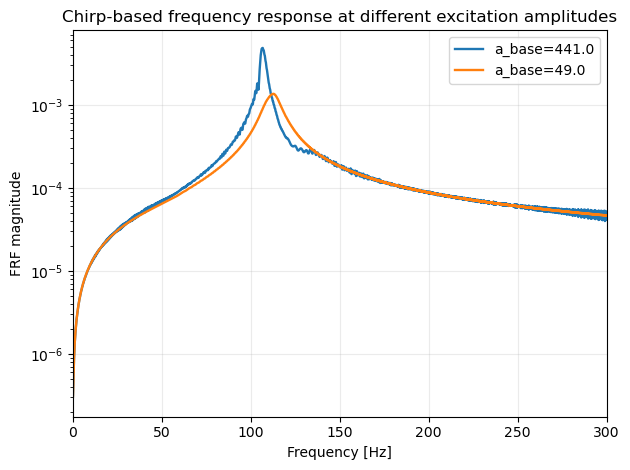

In [59]:
idx = -1
plt.semilogy(results[idx]["spectral"]["freq"], np.abs(results[idx]["spectral"]["FRF"]), lw=1.7, label=f"a_base={float(results[idx]['a_base'])*1000:0.1f}")
idx = 0
plt.semilogy(results[idx]["spectral"]["freq"], np.abs(results[idx]["spectral"]["FRF"]), lw=1.7, label=f"a_base={float(results[idx]['a_base'])*1000:0.1f}")

plt.xlabel(r"Frequency [Hz]")
plt.ylabel(r"FRF magnitude")
plt.title("Chirp-based frequency response at different excitation amplitudes")
plt.grid(alpha=0.25)
plt.legend()
plt.xlim(0, 300)
plt.tight_layout()
plt.show()



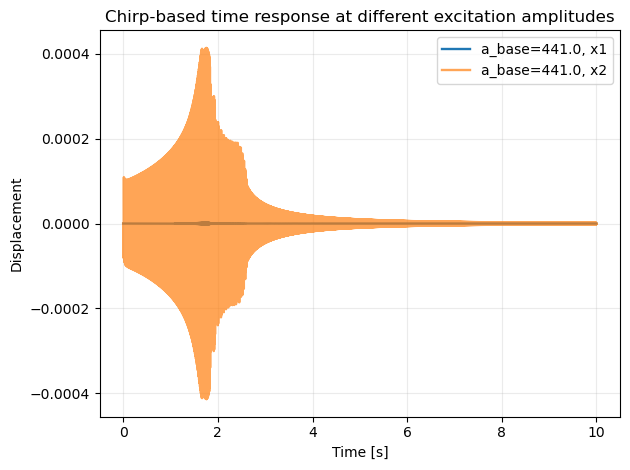

NameError: name 'dd' is not defined

In [60]:
idx = -1
plt.plot(results[idx]["t"], results[idx]["x1"], lw=1.7, label=f"a_base={float(results[idx]['a_base'])*1000:0.1f}, x1")
# idx = 0

plt.plot(results[idx]["t"], results[idx]["x2"], lw=1.7, label=f"a_base={float(results[idx]['a_base'])*1000:0.1f}, x2", alpha =0.7)
plt.xlabel(r"Time [s]")
plt.ylabel(r"Displacement")
plt.title("Chirp-based time response at different excitation amplitudes")
plt.grid(alpha=0.25)
plt.legend()
# plt.xlim(0, 300)
plt.tight_layout()
plt.show()

dd

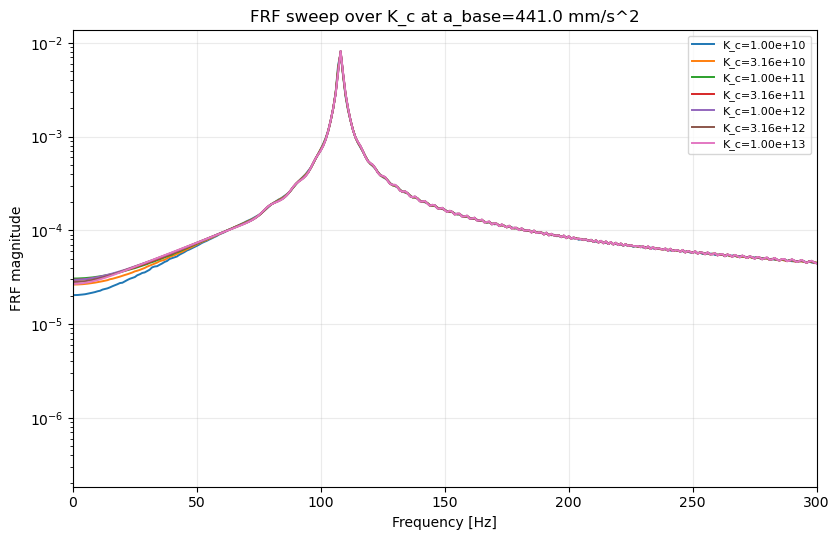

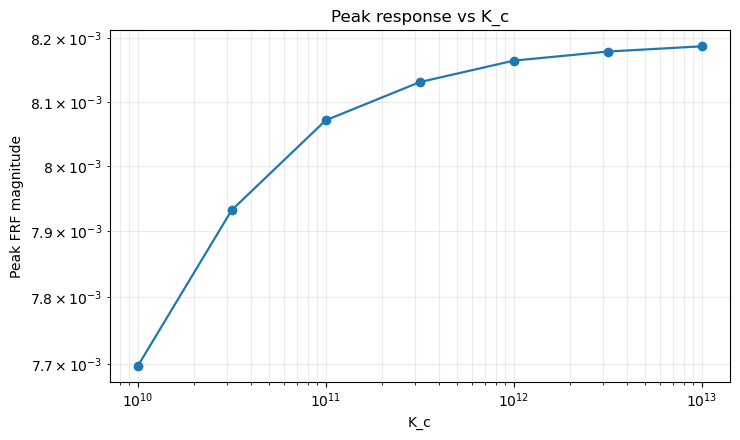

In [ ]:
# Sweep over K_c (hardening nonlinearity)
K_c_values = np.logspace(10, 13, 7)
a_base_ref = float(a_base_values[-1])

kc_sweep_results = []
K_c_original = K_c

for kc in K_c_values:
    K_c = float(kc)
    case = simulate_a_base(a_base_ref)

    freq = case["spectral"]["freq"]
    frf = np.abs(case["spectral"]["FRF"])

    peak_idx = np.argmax(frf)
    kc_sweep_results.append(
        {
            "K_c": K_c,
            "freq": freq,
            "FRF": frf,
            "peak_frf": frf[peak_idx],
            "peak_freq": freq[peak_idx],
        }
    )

# Restore the original parameter value
K_c = K_c_original

plt.figure(figsize=(8.5, 5.5))
for item in kc_sweep_results:
    plt.semilogy(item["freq"], item["FRF"], lw=1.4, label=f"K_c={item['K_c']:.2e}")

plt.xlabel("Frequency [Hz]")
plt.ylabel("FRF magnitude")
plt.title(f"FRF sweep over K_c at a_base={a_base_ref*1000:.1f} mm/s^2")
plt.grid(alpha=0.25)
plt.legend(fontsize=8)
plt.xlim(0, 300)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7.5, 4.5))
plt.loglog(
    [item["K_c"] for item in kc_sweep_results],
    [item["peak_frf"] for item in kc_sweep_results],
    "o-",
    lw=1.6,
)
plt.xlabel("K_c")
plt.ylabel("Peak FRF magnitude")
plt.title("Peak response vs K_c")
plt.grid(alpha=0.25, which="both")
plt.tight_layout()
plt.show()